In [2]:
import path from "node:path";
import os from "node:os";
import fs from "node:fs"
import pl from 'npm:nodejs-polars';


interface ZshHistoryRow {
  id?: number;
  timestamp: number;   // unix seconds
  command: string;
}

function extract() {
  const zshHistoryPath = path.join(
    os.homedir(),
    ".zsh_history"
  );
  const historyFile = fs.readFileSync(zshHistoryPath, "utf8");
  const lines = historyFile.split("\n");
  const rows = []
  for (const line of lines) {
    // format: : 1705071243:0;git status
    if (!line.startsWith(": ")) continue;

    const match = line.match(/^: (\d+):\d+;(.*)$/);
    if (!match) continue;

    rows.push({
      timestamp: Number(match[1]),
      command: match[2].split(" ")[0], // why not the full command? i don't want to mess with secrets and env vars
    });

  }
  return rows
}

function displayTable(df: pl.DataFrame, limit:number = 10) {
  console.log(df.shape)
  console.table(df.head(limit).toRecords());
}


const rows = extract()
const df = pl.DataFrame(rows)
displayTable(df)

{ height: 1884, width: 2 }
┌───────┬────────────┬─────────┐
│ (idx) │ timestamp  │ command │
├───────┼────────────┼─────────┤
│     0 │ 1763493968 │ "vite"  │
│     1 │ 1763493968 │ "npm"   │
│     2 │ 1763493968 │ "vite"  │
│     3 │ 1763493968 │ "npx"   │
│     4 │ 1763493968 │ "npm"   │
│     5 │ 1763493968 │ "npx"   │
│     6 │ 1763493968 │ "ls"    │
│     7 │ 1763493968 │ "npx"   │
│     8 │ 1763493968 │ "npm"   │
│     9 │ 1763493968 │ "npm"   │
└───────┴────────────┴─────────┘


In [3]:
displayTable(
  df
  .groupBy("command")
  .agg(pl.col("timestamp").count().alias("count"))
  .sort("count", true)
)

// web dev be like

{ height: 107, width: 2 }
┌───────┬──────────┬───────┐
│ (idx) │ command  │ count │
├───────┼──────────┼───────┤
│     0 │ "npm"    │   471 │
│     1 │ "git"    │   262 │
│     2 │ "ls"     │   219 │
│     3 │ "cd"     │   164 │
│     4 │ "npx"    │    87 │
│     5 │ "pyenv"  │    60 │
│     6 │ "python" │    42 │
│     7 │ "rm"     │    37 │
│     8 │ "pip"    │    34 │
│     9 │ "pytest" │    29 │
└───────┴──────────┴───────┘


In [14]:
const dfWithDateTime = df
.filter(pl.col("timestamp").neq(1763493968)) // something happend during this day, i did like a million commands at the same time 😟
.withColumn(
  pl
    .col("timestamp")
    .cast(pl.Float64)
    .mul(1000)
    .cast(pl.Datetime("ms"))        // cast to Polars datetime
    .alias("datetime")
).withColumn(
  pl.col("datetime").date    
    .hour().alias("hour")
)

console.log(dfWithDateTime.columns)
const aggregated = dfWithDateTime.groupBy(["hour"]).agg(pl.len().alias("count"))

displayTable(dfWithDateTime)

displayTable(aggregated)

[ "timestamp", "command", "datetime", "hour" ]
{ height: 884, width: 4 }
┌───────┬────────────┬────────────┬──────────────────────────┬──────┐
│ (idx) │ timestamp  │ command    │ datetime                 │ hour │
├───────┼────────────┼────────────┼──────────────────────────┼──────┤
│     0 │ 1763493765 │ "starship" │ 2025-11-18T19:22:45.000Z │   19 │
│     1 │ 1763493767 │ "ls"       │ 2025-11-18T19:22:47.000Z │   19 │
│     2 │ 1763493876 │ "l"        │ 2025-11-18T19:24:36.000Z │   19 │
│     3 │ 1763493878 │ "ls"       │ 2025-11-18T19:24:38.000Z │   19 │
│     4 │ 1763493885 │ "cd"       │ 2025-11-18T19:24:45.000Z │   19 │
│     5 │ 1763493886 │ "ls"       │ 2025-11-18T19:24:46.000Z │   19 │
│     6 │ 1763493926 │ "starship" │ 2025-11-18T19:25:26.000Z │   19 │
│     7 │ 1763493927 │ "ls"       │ 2025-11-18T19:25:27.000Z │   19 │
│     8 │ 1763493956 │ "starship" │ 2025-11-18T19:25:56.000Z │   19 │
│     9 │ 1763493957 │ "ls"       │ 2025-11-18T19:25:57.000Z │   19 │
└───────┴────────

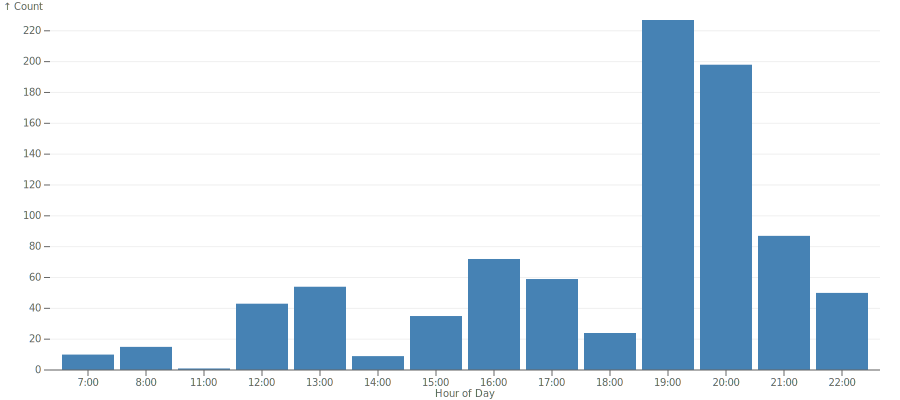

In [ ]:
import * as Plot from "npm:@observablehq/plot";
import { document } from "jsr:@manzt/jupyter-helper";

const records = aggregated.toRecords();


Plot.plot({
  width: 900,
  marginLeft: 50,
  marks: [
    Plot.barY(records, {
      x: "hour",
      y: "count",
      fill: "steelblue", 
    }),
    Plot.ruleY([0]),
  ],
  x: {
    label: "Hour of Day",
    tickFormat: d => `${d}:00`,
  },
  y: {
    label: "Count",
    grid: true,

  },
  style: {
    color: "#666", 
  },
  document,
});

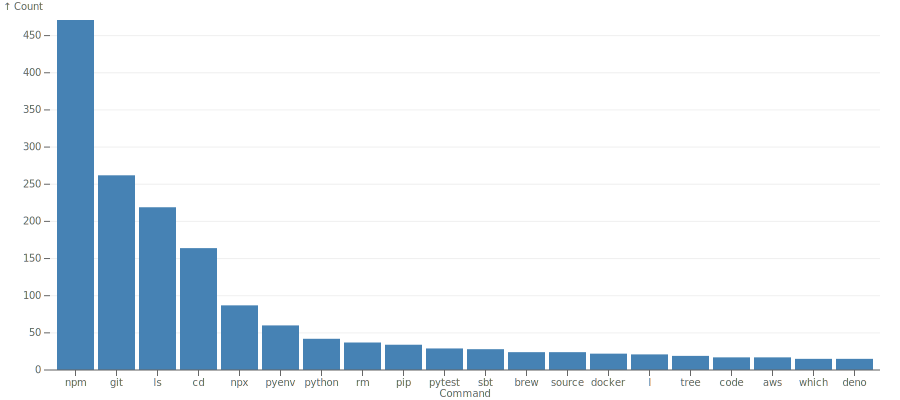

In [40]:
const commandsDf = df
  // .filter(pl.col("timestamp").neq(1763493968))
  .groupBy(["command"]).agg(pl.len().alias("count")).sort("count", true).limit(20)
const records2 = commandsDf.toRecords();


Plot.plot({
  width: 900,
  marginLeft: 50,
  marks: [
    Plot.barY(records2, {
      x: "command",
      y: "count",
      fill: "steelblue",
    }),
    Plot.ruleY([0]),
  ],
  x: {
    label: "Command",
    domain: records2.map(d => d.command),  // Preserve sort order from Polars

  },
  y: {
    label: "Count",
    grid: true,

  },
  style: {
    color: "#666",
  },
  document,
});

shape: (7, 2)
┌─────────┬───────┐
│ weekday ┆ count │
│ ---     ┆ ---   │
│ str     ┆ u32   │
╞═════════╪═══════╡
│ Tue     ┆ 168   │
│ Sat     ┆ 230   │
│ Sun     ┆ 92    │
│ Mon     ┆ 137   │
│ Fri     ┆ 78    │
│ Wed     ┆ 98    │
│ Thu     ┆ 81    │
└─────────┴───────┘


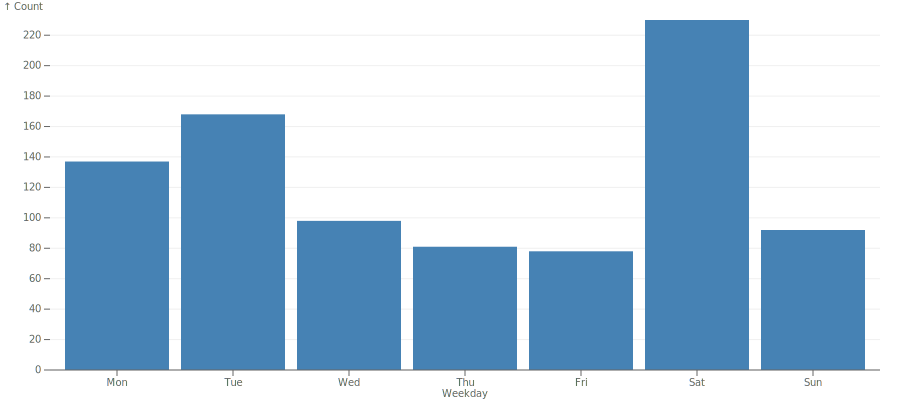

In [45]:
const dfWithWeekday = dfWithDateTime
  .withColumn(
    pl.col("datetime")
    .date.strftime("%a")
    .alias("weekday")
  )

const groupedByWeekday = dfWithWeekday
  .groupBy("weekday")
  .agg(pl.len().alias("count"))
  

console.log(groupedByWeekday.toString())

Plot.plot({
  width: 900,
  marginLeft: 50,
  marks: [
    Plot.barY(groupedByWeekday.toRecords(), {
      x: "weekday",
      y: "count",
      fill: "steelblue",
    }),
    Plot.ruleY([0]),
  ],
  x: {
    label: "Weekday",
    domain: ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"],  // Preserve sort order from Polars

  },
  y: {
    label: "Count",
    grid: true,

  },
  style: {
    color: "#666",
  },
  document,
});

shape: (3, 2)
┌───────┬───────┐
│ month ┆ count │
│ ---   ┆ ---   │
│ str   ┆ u32   │
╞═══════╪═══════╡
│ Nov   ┆ 107   │
│ Jan   ┆ 325   │
│ Dec   ┆ 452   │
└───────┴───────┘


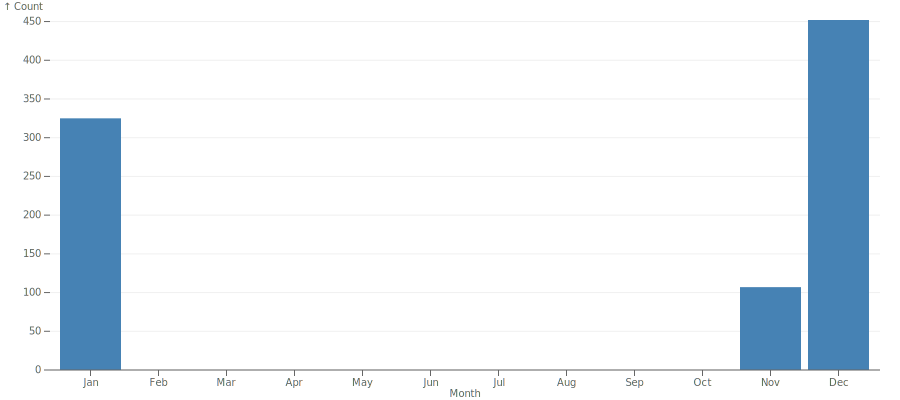

In [46]:
const dfWithMonth = dfWithDateTime
  .withColumn(
    pl.col("datetime")
    .date.strftime("%b")  // Short month name (Jan, Feb, etc.)
    .alias("month")
  )

const groupedByMonth = dfWithMonth
  .groupBy("month")
  .agg(pl.len().alias("count"))

console.log(groupedByMonth.toString())

Plot.plot({
  width: 900,
  marginLeft: 50,
  marks: [
    Plot.barY(groupedByMonth.toRecords(), {
      x: "month",
      y: "count",
      fill: "steelblue",
    }),
    Plot.ruleY([0]),
  ],
  x: {
    label: "Month",
    domain: ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"],
  },
  y: {
    label: "Count",
    grid: true,
  },
  style: {
    color: "#666",
  },
  document,
});